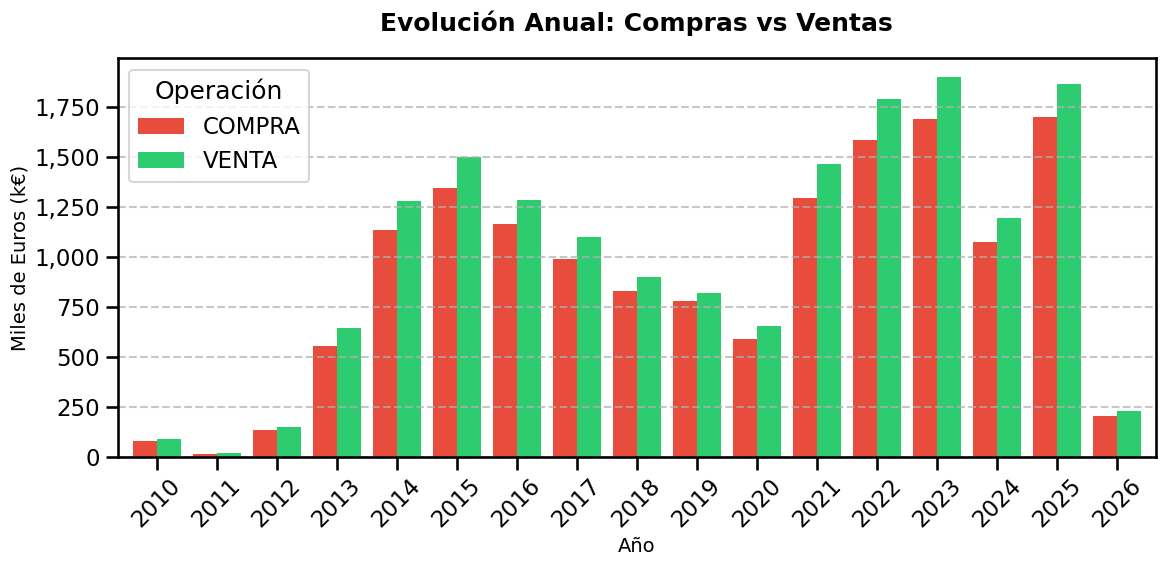

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Cargar datos
df = pd.read_excel('../data/processed/datos.xlsx')

# 2. Crear columna de AÑO
df['AÑO'] = df['FECHA'].dt.year

# 3. Agrupar por Año y Tipo de Operación y DIVIDIR ENTRE 1000
# Esto convierte los Euros en "Miles de Euros"
resumen_anual_k = df.groupby(['AÑO', 'TIPO_OPERACION'])['IMPORTE_NETO'].sum().unstack() / 1000

# 4. Gráfico profesional
# Nota: Quitamos el plt.figure previo porque pandas.plot crea su propia figura con figsize
ax = resumen_anual_k.plot(kind='bar', figsize=(12, 6), color=['#e74c3c', '#2ecc71'], width=0.8)

# Configuración de estética
sns.set_context("talk") 
plt.title('Evolución Anual: Compras vs Ventas', fontsize=18, pad=20, fontweight='bold')
plt.ylabel('Miles de Euros (k€)', fontsize=14)
plt.xlabel('Año', fontsize=14)
plt.xticks(rotation=45) # Rotamos un poco para que no se choquen si hay muchos años
plt.legend(title='Operación', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Formatear el eje Y para que ponga el separador de miles (ej: 1.500 en vez de 1500)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

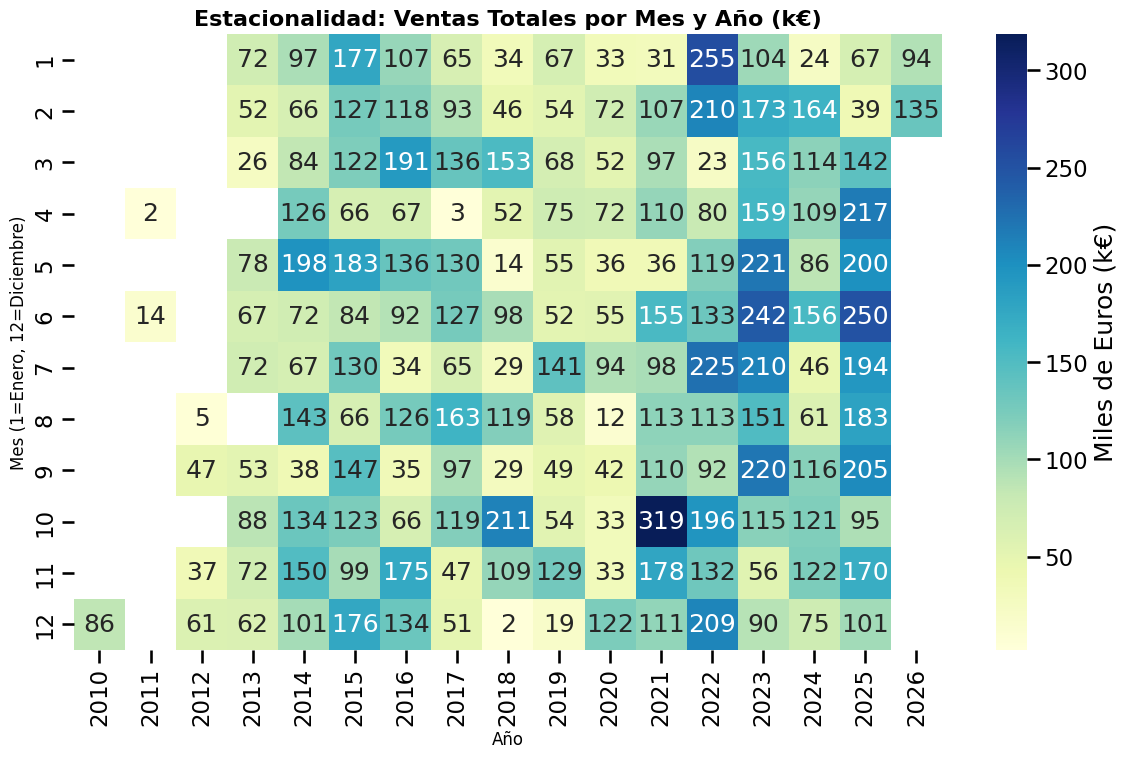

In [8]:
# Preparar datos: Solo Ventas y crear columnas de Año y Mes
df_ventas = df[df['TIPO_OPERACION'] == 'VENTA'].copy()
df_ventas['AÑO'] = df_ventas['FECHA'].dt.year
df_ventas['MES'] = df_ventas['FECHA'].dt.month

# Crear matriz para el Heatmap (Meses en filas, Años en columnas)
matrix = df_ventas.pivot_table(index='MES', columns='AÑO', values='IMPORTE_NETO', aggfunc='sum') / 1000

plt.figure(figsize=(14, 8))
# Corregido: usamos cbar_kws con un diccionario para el label
sns.heatmap(matrix, annot=True, fmt=".0f", cmap="YlGnBu", 
            cbar_kws={'label': 'Miles de Euros (k€)'})

plt.title('Estacionalidad: Ventas Totales por Mes y Año (k€)', fontsize=16, fontweight='bold')
plt.ylabel('Mes (1=Enero, 12=Diciembre)', fontsize=12)
plt.xlabel('Año', fontsize=12)
plt.show()

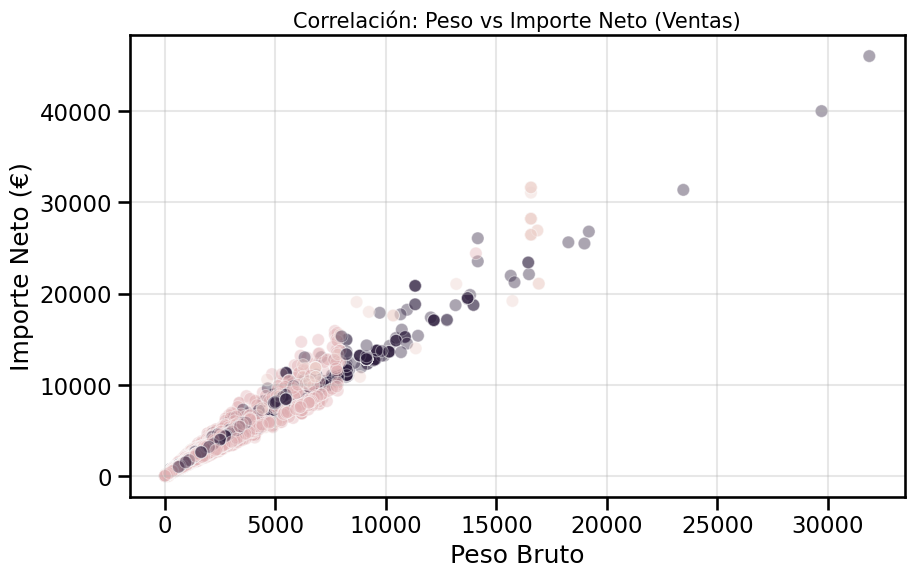

Coeficiente de correlación de Pearson: 0.98


In [9]:
plt.figure(figsize=(10, 6))
# Quitamos los logaritmos si tus datos son más o menos estables
sns.scatterplot(data=df_ventas, x='PESO_BRUTO', y='IMPORTE_NETO', alpha=0.4, hue='FAMILIA', legend=False)
plt.title('Correlación: Peso vs Importe Neto (Ventas)', fontsize=15)
plt.xlabel('Peso Bruto')
plt.ylabel('Importe Neto (€)')
plt.grid(True, alpha=0.3)
plt.show()

corr = df_ventas['PESO_BRUTO'].corr(df_ventas['IMPORTE_NETO'])
print(f"Coeficiente de correlación de Pearson: {corr:.2f}")

<Figure size 1000x500 with 0 Axes>

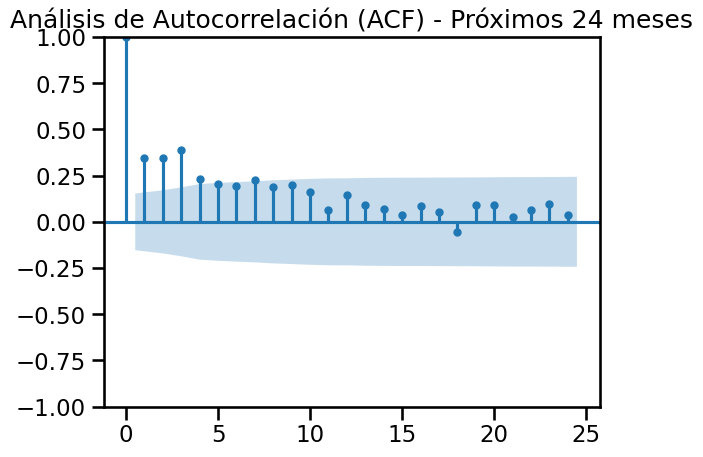

In [10]:
from statsmodels.graphics.tsaplots import plot_acf

# Agrupamos por mes
serie_temporal = df_ventas.groupby(df_ventas['FECHA'].dt.to_period('M'))['IMPORTE_NETO'].sum()

# Dibujamos la autocorrelación de los últimos 24 meses (2 años)
plt.figure(figsize=(10, 5))
plot_acf(serie_temporal, lags=24)
plt.title('Análisis de Autocorrelación (ACF) - Próximos 24 meses')
plt.show()

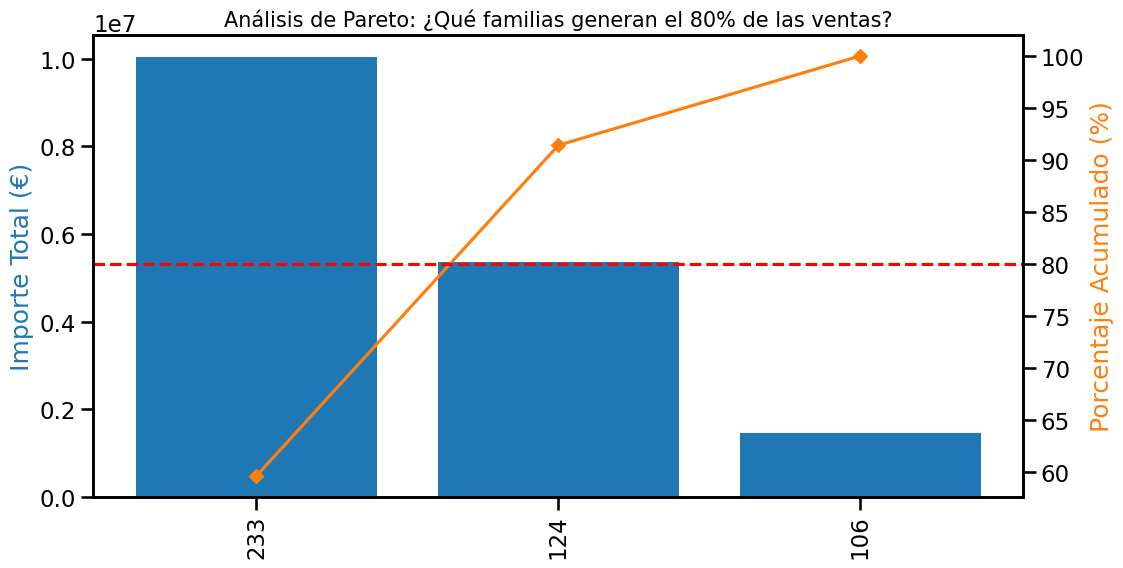

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Agrupar ventas por familia y ordenar
pareto_df = df_ventas.groupby('FAMILIA')['IMPORTE_NETO'].sum().sort_values(ascending=False).reset_index()

# 2. Calcular el porcentaje acumulado
pareto_df['cum_percentage'] = 100 * pareto_df['IMPORTE_NETO'].cumsum() / pareto_df['IMPORTE_NETO'].sum()

# 3. Gráfico de Pareto
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras para el importe
ax1.bar(pareto_df['FAMILIA'].astype(str), pareto_df['IMPORTE_NETO'], color="C0")
ax1.set_ylabel("Importe Total (€)", color="C0")

# Línea para el porcentaje acumulado
ax2 = ax1.twinx()
ax2.plot(pareto_df['FAMILIA'].astype(str), pareto_df['cum_percentage'], color="C1", marker="D", ms=7)
ax2.axhline(80, color="red", linestyle="--") # Línea del 80%
ax2.set_ylabel("Porcentaje Acumulado (%)", color="C1")

plt.title('Análisis de Pareto: ¿Qué familias generan el 80% de las ventas?', fontsize=15)
ax1.tick_params(axis='x', rotation=90)
plt.show()

In [12]:
import statsmodels.api as sm
import pandas as pd

# 1. Aseguramos que trabajamos con las ventas
df_ventas = df[df['TIPO_OPERACION'] == 'VENTA'].copy()

# 2. Limpieza rápida de Outliers (Percentil 95) para que el modelo sea estable
limite_superior = df_ventas['IMPORTE_NETO'].quantile(0.95)
df_clean = df_ventas[df_ventas['IMPORTE_NETO'] < limite_superior].copy()

# 3. Preparar las variables X (lo que predice) e y (lo que queremos saber)
# Usamos PESO_BRUTO y MES como ejemplo de regresión multivariable
X = df_clean[['PESO_BRUTO', 'MES']] 
X = sm.add_constant(X) # Obligatorio para que el modelo tenga punto de partida (intercept)
y = df_clean['IMPORTE_NETO']

# 4. Entrenar el modelo
modelo = sm.OLS(y, X).fit()

# 5. Mostrar resultados
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:           IMPORTE_NETO   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                 7.225e+04
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:24:05   Log-Likelihood:                -41282.
No. Observations:                5533   AIC:                         8.257e+04
Df Residuals:                    5530   BIC:                         8.259e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        171.3212     13.446     12.741      0.0

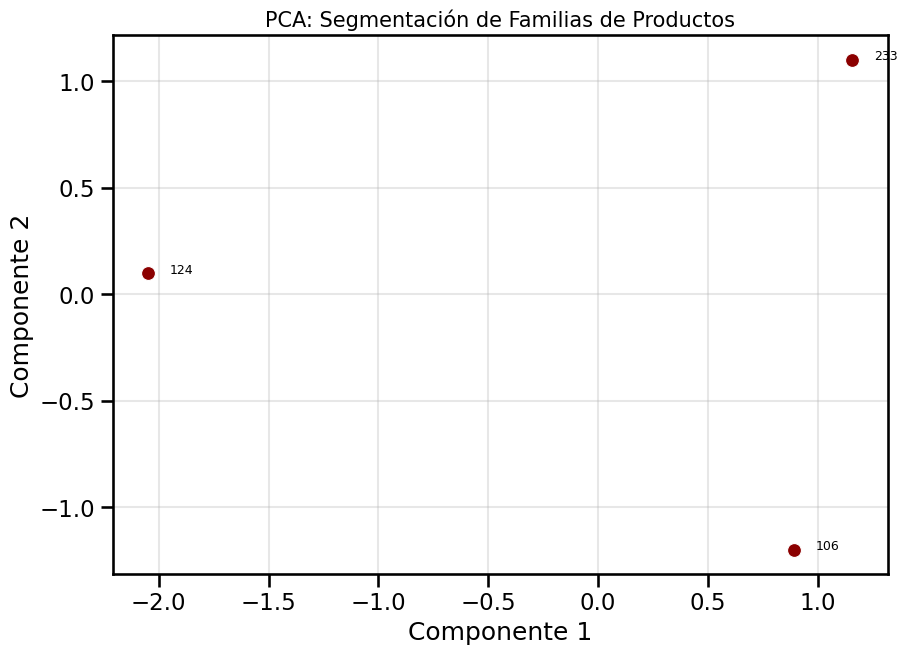

Varianza explicada por los 2 componentes: 100.00%


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparar datos: Queremos ver cómo se comportan las Familias
# Calculamos: Importe medio, Peso medio y Número de ventas por familia
pca_data = df_ventas.groupby('FAMILIA').agg({
    'IMPORTE_NETO': 'mean',
    'PESO_BRUTO': 'mean',
    'FECHA': 'count' # Frecuencia de ventas
}).rename(columns={'FECHA': 'FRECUENCIA'})

# 2. Normalizar (Muy importante: PCA es sensible a las escalas)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

# 3. Ejecutar PCA (Reducir a 2 componentes para poder graficar)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# 4. Crear DataFrame para el gráfico
pca_df = pd.DataFrame(data=pca_result, columns=['Componente 1', 'Componente 2'])
pca_df['FAMILIA'] = pca_data.index

# 5. Visualizar
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='Componente 1', y='Componente 2', s=100, color='darkred')

# Añadir etiquetas a los puntos para saber qué familia es cada una
for i in range(pca_df.shape[0]):
    plt.text(pca_df['Componente 1'][i]+0.1, pca_df['Componente 2'][i], 
             pca_df['FAMILIA'][i], fontsize=9)

plt.title('PCA: Segmentación de Familias de Productos', fontsize=15)
plt.grid(True, alpha=0.3)
plt.show()

# Explicación de las varianzas
print(f"Varianza explicada por los 2 componentes: {sum(pca.explained_variance_ratio_)*100:.2f}%")